# Visualization for Robust Offline RL

This notebook loads `metrics.json` files from `results/raw_metrics/` and calls
the reusable plotting utilities defined in `src/visualization.py`.

Figures are saved under an **environment-first** directory layout:

```text
results/
└── figures/
    └── paper_ready/
        └── <env>/
            ├── heatmaps/
            │   └── <noise_type>/
            ├── gain_heatmaps/
            │   └── <noise_type>/
            ├── curves/
            │   ├── dim_curves/
            │   │   └── <noise_type>/
            │   └── scale_curves/
            │       └── <noise_type>/
            ├── rankings/
            └── summaries/
```

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root containing 'src'.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from src.visualization import (
    RAW_METRICS_DIR,
    PAPER_READY_DIR,
    METHOD_LABELS,
    METHOD_ORDER,
    load_metrics_df,
    split_metrics_frames,
    get_available_methods,
    plot_method_heatmap,
    plot_multi_method_heatmaps,
    plot_relative_gain_heatmap,
    plot_average_gain_bar,
    plot_dim_curve_with_error,
    plot_scale_curve_with_error,
    plot_overall_ranking,
    plot_overall_ranking_by_noise_type,
)

PROJECT_ROOT: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 2

In [2]:
# ------------------------------------------------------------
# Load all metrics
# ------------------------------------------------------------
df_all = load_metrics_df(RAW_METRICS_DIR)
df_true, df_noisy = split_metrics_frames(df_all)

print("RAW_METRICS_DIR:", RAW_METRICS_DIR)
print("PAPER_READY_DIR:", PAPER_READY_DIR)
print("Total rows:", len(df_all))
print("Noisy rows:", len(df_noisy))
print("True-only rows:", len(df_true))

available_methods = get_available_methods(df_all, include_true_only=True)
available_noisy_methods = get_available_methods(df_noisy, include_true_only=False)

print("Available methods:", available_methods)
print("Available noisy methods:", available_noisy_methods)

display(df_all.head())

RAW_METRICS_DIR: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/raw_metrics
PAPER_READY_DIR: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready
Total rows: 889
Noisy rows: 888
True-only rows: 1
Available methods: ['true_only', 'disentangled_cov', 'disentangled_hsic', 'disentangled_barlow', 'disentangled_dcor', 'disentangled_infonce', 'disentangled_l1', 'plain', 'raw_noisy']
Available noisy methods: ['disentangled_cov', 'disentangled_hsic', 'disentangled_barlow', 'disentangled_dcor', 'disentangled_infonce', 'disentangled_l1', 'plain', 'raw_noisy']


,method,env,seed,normalized_score,noise_dim,noise_scale,noise_type,path,method_label
0,disentangled_barlow,halfcheetah-medium-v2,1,39.763122,10,0.5,nonlinear,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...,Barlow
1,disentangled_barlow,halfcheetah-medium-v2,2,38.726410,10,0.5,nonlinear,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...,Barlow
2,disentangled_barlow,halfcheetah-medium-v2,3,37.217300,10,0.5,nonlinear,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...,Barlow
3,disentangled_barlow,halfcheetah-medium-v2,1,41.128875,10,1.0,concat,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...,Barlow
4,disentangled_barlow,halfcheetah-medium-v2,1,37.822542,10,1.0,nonlinear,/mnt/d/CSE5100-Deep Reinforcement Learning/rob...,Barlow


In [3]:
# ------------------------------------------------------------
# Tunable runtime parameters
# ------------------------------------------------------------
ENV_NAME = "halfcheetah-medium-v2"
NOISE_TYPE = "nonlinear"

HEATMAP_METHODS = [
    "plain",
    "disentangled_barlow",
    "disentangled_dcor",
    "raw_noisy",
]

GAIN_METHOD = "disentangled_barlow"
GAIN_BASELINE = "raw_noisy"

GAIN_BAR_METHODS = [
    "disentangled_cov",
    "disentangled_hsic",
    "disentangled_barlow",
    "disentangled_dcor",
    "disentangled_infonce",
    "disentangled_l1",
    "plain",
]

CURVE_METHODS = [
    "disentangled_barlow",
    "disentangled_dcor",
    "plain",
    "raw_noisy",
]

FIXED_SCALE = 1.0
FIXED_DIM = 20

RANKING_METHODS = [
    "disentangled_cov",
    "disentangled_hsic",
    "disentangled_barlow",
    "disentangled_dcor",
    "disentangled_infonce",
    "disentangled_l1",
    "plain",
    "raw_noisy",
]

SAVE_FIGURES = True

## Heatmaps

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/heatmaps/nonlinear/heatmap_disentangled_barlow_mean.png


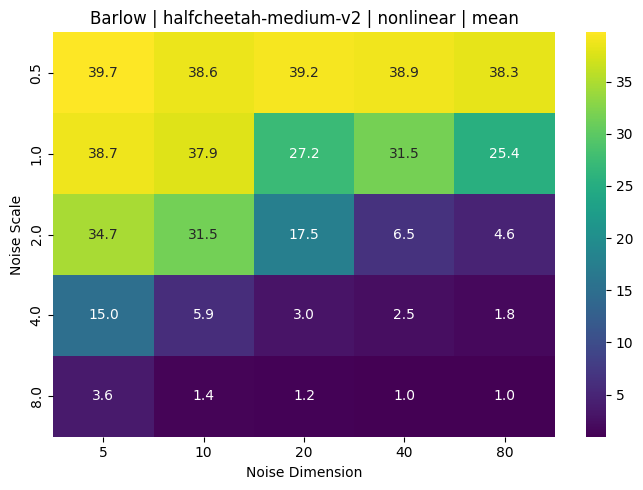

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/heatmaps/nonlinear/heatmap_plain_mean.png


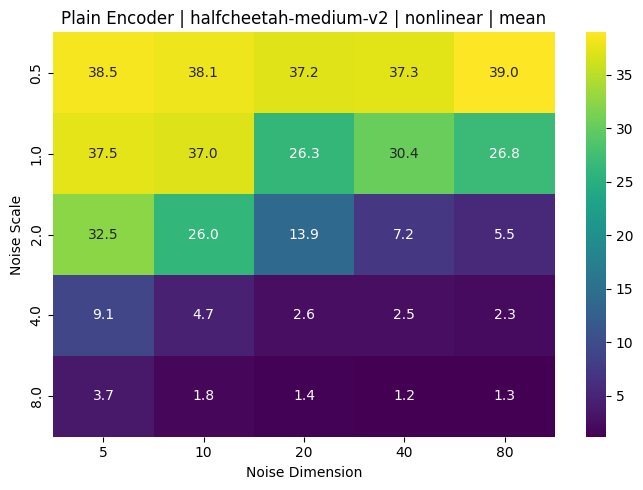

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/heatmaps/nonlinear/heatmap_raw_noisy_mean.png


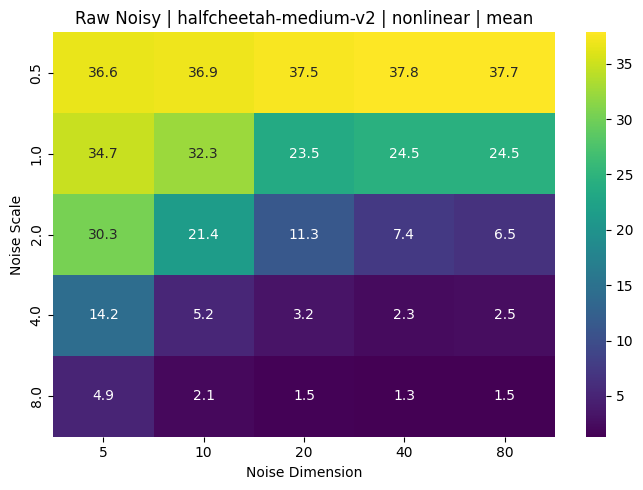

PosixPath('/mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/heatmaps/nonlinear/heatmap_raw_noisy_mean.png')

In [4]:
plot_method_heatmap(
    df_noisy,
    method="disentangled_barlow",
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)

plot_method_heatmap(
    df_noisy,
    method="plain",
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)

plot_method_heatmap(
    df_noisy,
    method="raw_noisy",
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/heatmaps/nonlinear/heatmap_compare_plain_disentangled_barlow_disentangled_dcor_raw_noisy.png


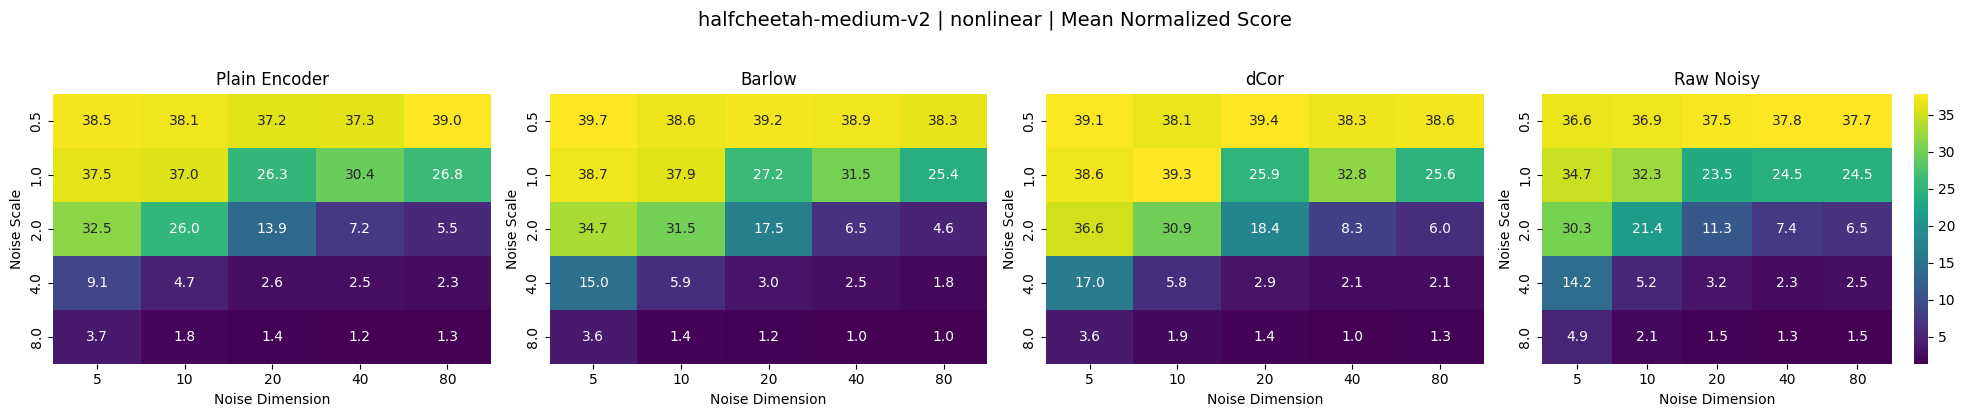

PosixPath('/mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/heatmaps/nonlinear/heatmap_compare_plain_disentangled_barlow_disentangled_dcor_raw_noisy.png')

In [5]:
plot_multi_method_heatmaps(
    df_noisy,
    methods=HEATMAP_METHODS,
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)

## Relative Gain

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/gain_heatmaps/nonlinear/gain_disentangled_barlow_vs_raw_noisy.png


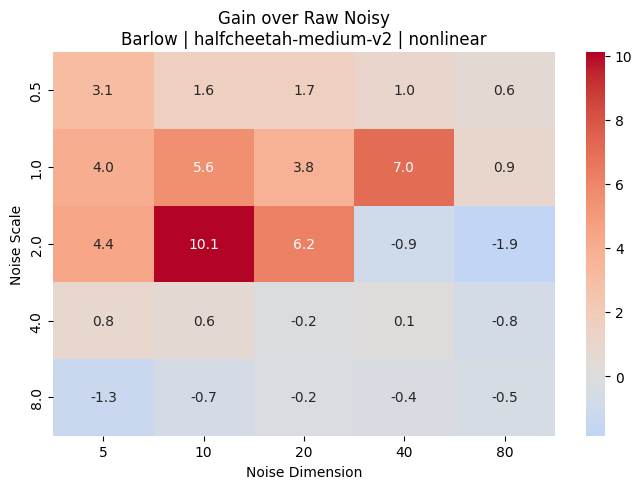

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/gain_heatmaps/nonlinear/gain_disentangled_dcor_vs_plain.png


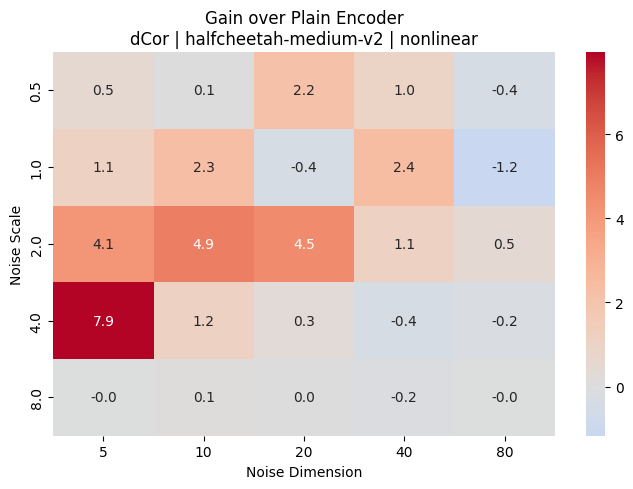

PosixPath('/mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/gain_heatmaps/nonlinear/gain_disentangled_dcor_vs_plain.png')

In [6]:
plot_relative_gain_heatmap(
    df_noisy,
    method=GAIN_METHOD,
    baseline=GAIN_BASELINE,
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)

plot_relative_gain_heatmap(
    df_noisy,
    method="disentangled_dcor",
    baseline="plain",
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/summaries/avg_gain_bar_nonlinear_vs_raw_noisy.png


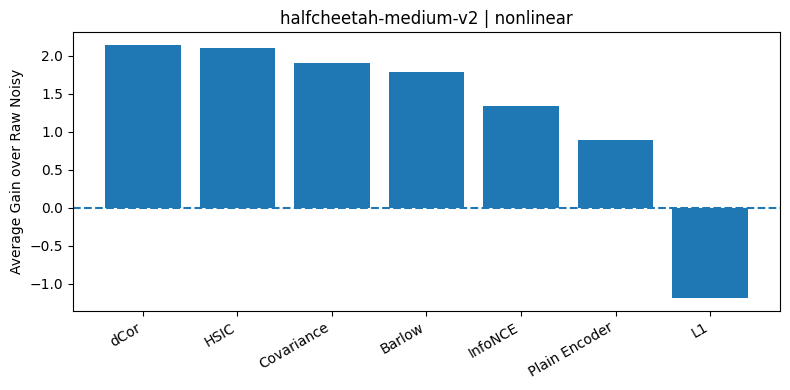

,method,avg_gain
3,disentangled_dcor,2.138460
1,disentangled_hsic,2.105159
0,disentangled_cov,1.895664
2,disentangled_barlow,1.789499
4,disentangled_infonce,1.340950
6,plain,0.885104
5,disentangled_l1,-1.187738


In [7]:
gain_df = plot_average_gain_bar(
    df_noisy,
    methods=GAIN_BAR_METHODS,
    baseline=GAIN_BASELINE,
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    save=SAVE_FIGURES,
)
gain_df

## Mean ± Std Curves

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/curves/dim_curves/nonlinear/dim_curve_scale_1p0.png


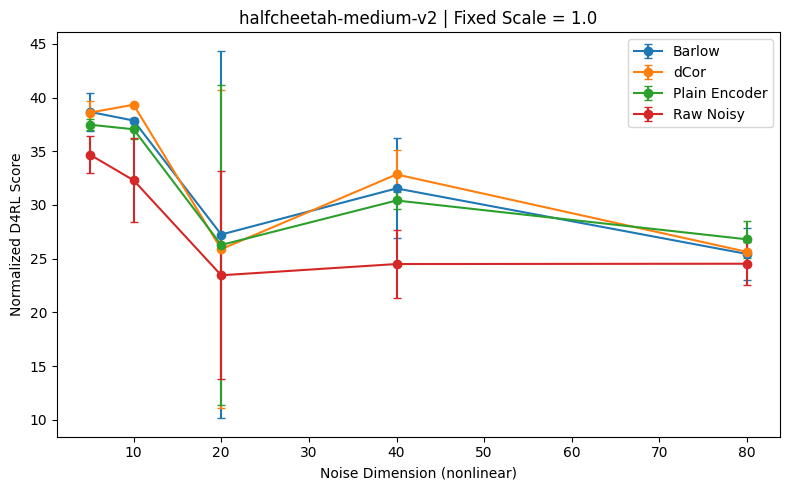

PosixPath('/mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/curves/dim_curves/nonlinear/dim_curve_scale_1p0.png')

In [8]:
plot_dim_curve_with_error(
    df_noisy,
    methods=CURVE_METHODS,
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    fixed_scale=FIXED_SCALE,
    save=SAVE_FIGURES,
)

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/curves/scale_curves/nonlinear/scale_curve_dim_20.png


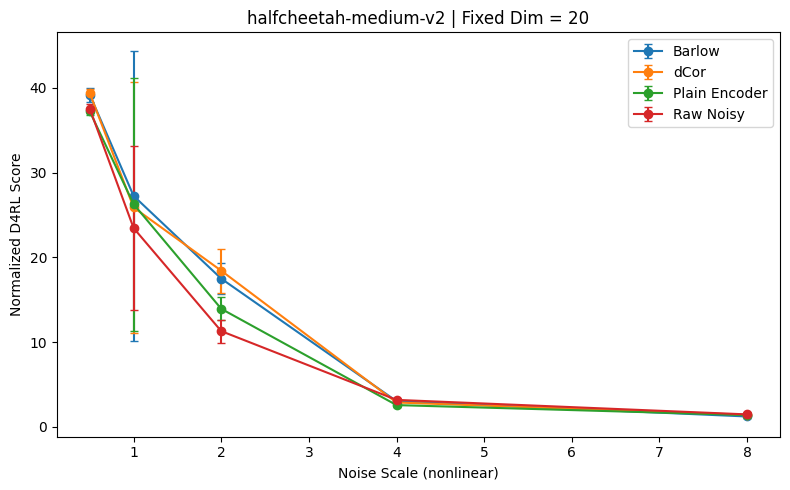

PosixPath('/mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/curves/scale_curves/nonlinear/scale_curve_dim_20.png')

In [9]:
plot_scale_curve_with_error(
    df_noisy,
    methods=CURVE_METHODS,
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    fixed_dim=FIXED_DIM,
    save=SAVE_FIGURES,
)

## Overall Rankings

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/rankings/overall_ranking_nonlinear.png


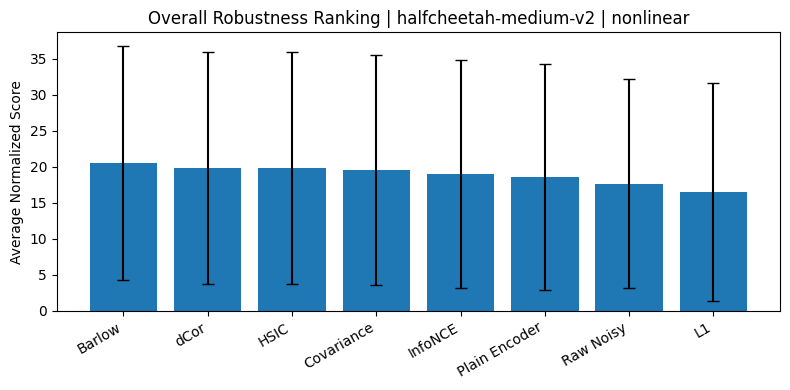

,method,mean,std
0,disentangled_barlow,20.571494,16.232668
2,disentangled_dcor,19.806260,16.120820
3,disentangled_hsic,19.772960,16.082951
1,disentangled_cov,19.563465,15.933335
4,disentangled_infonce,19.008751,15.812638
6,plain,18.552904,15.667565
7,raw_noisy,17.667801,14.456754
5,disentangled_l1,16.480063,15.111492


In [10]:
ranking_df = plot_overall_ranking(
    df_noisy,
    env=ENV_NAME,
    noise_type=NOISE_TYPE,
    methods=RANKING_METHODS,
    save=SAVE_FIGURES,
)
ranking_df

Saved: /mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/rankings/overall_ranking_by_noise_type.png


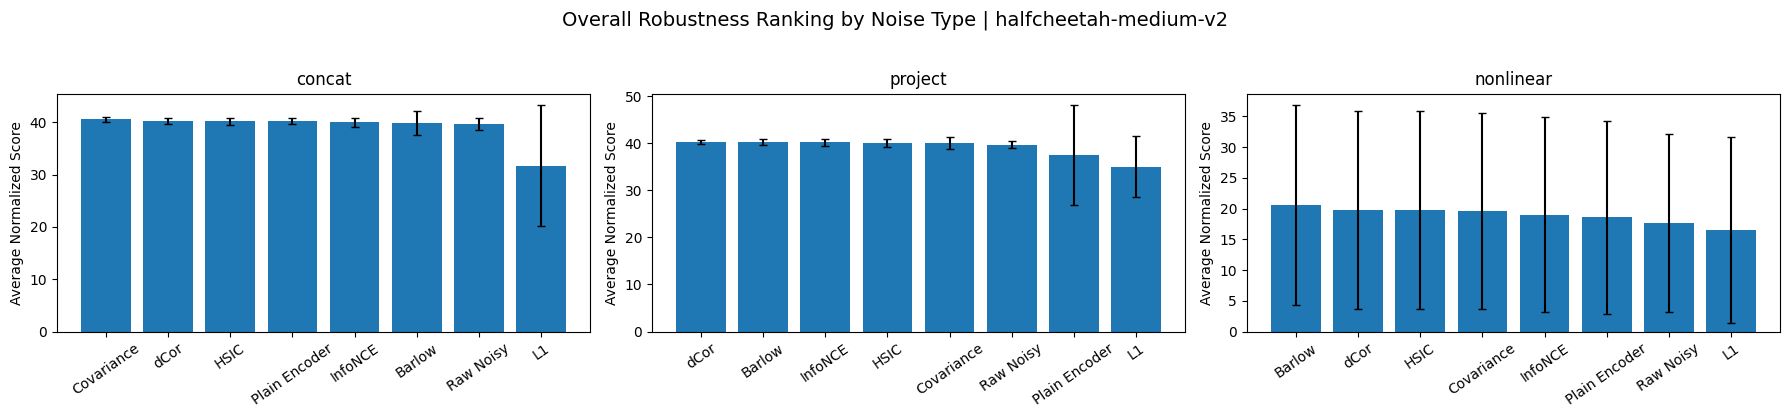

PosixPath('/mnt/d/CSE5100-Deep Reinforcement Learning/robust-offline-rl-disentanglement/results/figures/paper_ready/halfcheetah-medium-v2/rankings/overall_ranking_by_noise_type.png')

In [11]:
plot_overall_ranking_by_noise_type(
    df_noisy,
    env=ENV_NAME,
    methods=RANKING_METHODS,
    save=SAVE_FIGURES,
)

## Notes

- `true_only` does not belong to the noise grid, so it is intentionally excluded from
  heatmaps and dim/scale curves.
- If needed, `true_only` can be added later as a horizontal reference line in trend plots
  or as a separate summary entry in tables.